In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from model_layers import *

In [2]:
with open("names.txt", "r") as f:
    words = f.read().splitlines()

In [3]:
chars = ["."] + sorted(list(set("".join(words))))
stoi, itos = {}, {}
for i, char in enumerate(chars):
    stoi[char] = i
    itos[i] = char

vocab_size = len(stoi)

In [4]:
block_size = 8

def build_dataset(words):
    X, Y = [], []

    for word in words:
        context = [0] * block_size
        for ch in word + ".":
            idx = stoi[ch]
            X.append(context)
            Y.append(idx)
            context = context[1:] + [idx]

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1: n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182414, 8]) torch.Size([182414])
torch.Size([22749, 8]) torch.Size([22749])
torch.Size([22983, 8]) torch.Size([22983])


In [5]:
torch.manual_seed(42)

In [24]:
n_embed = 24
n_hidden = 128

model = Sequential(
    [
        Embedding(vocab_size, n_embed),
        FlattenConsecutive(2), Linear(n_embed * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
        FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
        FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
        Linear(n_hidden, vocab_size)
    ]
)

with torch.no_grad():
    model.layers[-1].weight *= 0.1

parameters = model.parameters()
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True

76579


In [25]:
max_steps = 200_000
batch_size = 64
lossi = []

for i in range(max_steps):

    # create minibatch
    ix = torch.randint(0, Xtr.shape[0], (batch_size,))
    Xb, Yb = Xtr[ix], Ytr[ix]

    # forward pass
    logits = model(Xb)
    loss = F.cross_entropy(logits, Yb)

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 100_000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 10_000 == 0:
        print(f"{i:7d}/{max_steps:7d}: {loss.item():.4f}")
    lossi.append(loss.log10().item())

      0/ 200000: 3.3108
  10000/ 200000: 2.2785
  20000/ 200000: 1.8582
  30000/ 200000: 2.0575
  40000/ 200000: 2.0864
  50000/ 200000: 1.7141
  60000/ 200000: 1.6532
  70000/ 200000: 1.7693
  80000/ 200000: 1.8922
  90000/ 200000: 1.9451
 100000/ 200000: 1.7173
 110000/ 200000: 1.7110
 120000/ 200000: 1.5767
 130000/ 200000: 1.8201
 140000/ 200000: 1.5491
 150000/ 200000: 1.7189
 160000/ 200000: 1.5135
 170000/ 200000: 1.6437
 180000/ 200000: 1.6572
 190000/ 200000: 1.9754


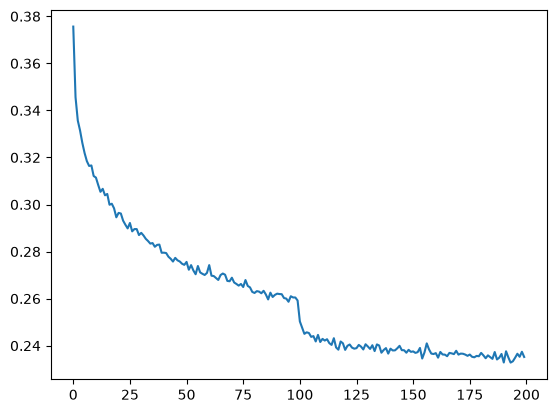

In [26]:
plt.plot(torch.tensor(lossi).view(-1, 1000).mean(1))

In [27]:
for layer in model.layers:
    layer.training = False

In [28]:
@torch.no_grad()
def split_loss(split):

    x, y = {
        "train": (Xtr, Ytr),
        "val": (Xdev, Ydev),
        "test": (Xte, Yte)
    }[split]

    logits = model(x)
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss("train")
split_loss("val")

train 1.6954354047775269
val 2.0252344608306885


In [29]:
for _ in range(20):

    out = []
    context = [0] * block_size
    while True:

        x = torch.tensor([context])
        logits = model(x)
        probs = F.softmax(logits, dim=1)

        idx = torch.multinomial(probs, replacement=True, num_samples=1).item()
        context = context[1:] + [idx]
        out.append(idx)
        if idx == 0:
            break

    print("".join(itos[i] for i in out))

jacobi.
matter.
aminah.
loya.
kadix.
joandre.
killa.
bhamere.
chimanicoluwa.
brinnon.
leiyn.
coralea.
romeva.
welle.
jaydence.
rofilee.
terryn.
julieann.
kierki.
uzaine.
